In [5]:
"""
Step 1 of 2 -- Dataset analysis / EDA for the "Credit Card Fraud Detection" dataset.

Run this on Kaggle as a notebook cell script attached to the dataset:
    https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
(Add it via "+ Add Input" in a new Kaggle Notebook; the file will appear at
/kaggle/input/creditcardfraud/creditcard.csv)

Citation for the dataset (cite this in the paper, not Kaggle itself):
  Dal Pozzolo, A., Caelen, O., Johnson, R. A., & Bontempi, G. (2015).
  "Calibrating Probability with Undersampling for Unbalanced Classification."
  2015 IEEE Symposium Series on Computational Intelligence, 159-166.
  doi:10.1109/SSCI.2015.33

What this script does (no modelling yet -- pure data understanding, feeds the
manuscript's "Dataset" subsection):
  1. Loads the raw CSV and reports shape, dtypes, missing values.
  2. Reports the class-imbalance ratio (fraud vs. non-fraud).
  3. Descriptive statistics for Amount and Time, split by class.
  4. Correlation of each PCA feature (V1-V28) with the fraud label.
  5. Saves figures: class balance bar chart, Amount distribution (log scale)
     by class, transactions-per-hour histogram by class, and a correlation
     bar chart -- all to ./eda_outputs/.
  6. Prints a plain-text summary (paste this into the paper's dataset
     description / share as the "log").

Run:  python kaggle_01_eda.py
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# --- locate the data: Kaggle input path first, local fallback second ---
CANDIDATE_PATHS = [
    Path("/kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv"),
    Path(__file__).parent / "creditcard.csv",
    Path("creditcard.csv"),
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "creditcard.csv not found. On Kaggle: add the 'mlg-ulb/creditcardfraud' "
        "dataset as a notebook input. Locally: place creditcard.csv next to this script."
    )

OUT_DIR = Path("eda_outputs") if Path("/kaggle/working").exists() else Path(__file__).parent / "eda_outputs"
OUT_DIR.mkdir(exist_ok=True)

V_COLS = [f"V{i}" for i in range(1, 29)]


def main():
    print(f"Loading {DATA_PATH} ...")
    df = pd.read_csv(DATA_PATH)
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Missing values total: {int(df.isna().sum().sum())}")
    print(f"Duplicate rows: {int(df.duplicated().sum())}")

    n = len(df)
    n_fraud = int(df["Class"].sum())
    n_legit = n - n_fraud
    print("\n--- Class balance ---")
    print(f"Legitimate: {n_legit} ({100*n_legit/n:.4f}%)")
    print(f"Fraudulent: {n_fraud} ({100*n_fraud/n:.4f}%)")
    print(f"Imbalance ratio (legit:fraud): {n_legit/n_fraud:.1f}:1")

    print("\n--- Amount, by class ---")
    print(df.groupby("Class")["Amount"].describe())

    if "Time" in df.columns:
        df["hour"] = (df["Time"] % 86400) // 3600
        print("\n--- Transactions by hour-of-day (fraud rate) ---")
        hourly = df.groupby("hour")["Class"].agg(["count", "sum"])
        hourly["fraud_rate_pct"] = 100 * hourly["sum"] / hourly["count"]
        print(hourly)
    else:
        print("\n[WARN] No 'Time' column found; skipping hour-of-day analysis.")

    print("\n--- Correlation of V1-V28 with Class (top 10 by |corr|) ---")
    corr = df[V_COLS + ["Class"]].corr()["Class"].drop("Class")
    top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index).head(10)
    print(top_corr)

    # ---------------- Figures ----------------
    plt.figure(figsize=(4, 4))
    plt.bar(["Legitimate", "Fraud"], [n_legit, n_fraud], color=["#4C72B0", "#C44E52"])
    plt.yscale("log")
    plt.ylabel("Count (log scale)")
    plt.title("Class balance")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "class_balance.png", dpi=200)
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.hist(df.loc[df.Class == 0, "Amount"], bins=60, alpha=0.6, label="Legitimate", density=True)
    plt.hist(df.loc[df.Class == 1, "Amount"], bins=60, alpha=0.6, label="Fraud", density=True)
    plt.xscale("symlog")
    plt.xlabel("Amount (symlog scale)")
    plt.ylabel("Density")
    plt.title("Transaction amount distribution by class")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "amount_distribution.png", dpi=200)
    plt.close()

    if "hour" in df.columns:
        plt.figure(figsize=(7, 4))
        rate = df.groupby("hour")["Class"].mean() * 100
        plt.bar(rate.index, rate.values, color="#DD8452")
        plt.xlabel("Hour of day (derived from Time)")
        plt.ylabel("Fraud rate (%)")
        plt.title("Fraud rate by hour of day")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "fraud_rate_by_hour.png", dpi=200)
        plt.close()

    plt.figure(figsize=(6, 5))
    top_corr.sort_values().plot(kind="barh", color="#55A868")
    plt.xlabel("Pearson correlation with Class")
    plt.title("Top 10 |correlation| features vs. fraud label")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "feature_correlation.png", dpi=200)
    plt.close()

    summary = {
        "n_transactions": n,
        "n_fraud": n_fraud,
        "fraud_rate_pct": 100 * n_fraud / n,
        "n_features": len(V_COLS) + 1,  # + Amount
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }
    pd.Series(summary).to_csv(OUT_DIR / "dataset_summary.csv")
    print(f"\nFigures + summary written to {OUT_DIR}/")
    print("Copy dataset_summary.csv + the printed stats above into the paper's dataset subsection.")


if __name__ == "__main__":
    main()


NameError: name '__file__' is not defined

In [6]:
"""
Step 1 of 2 -- Dataset Analysis / EDA
Credit Card Fraud Detection Dataset

Dataset:
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Dataset path:
 /kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv

Dataset citation:
Dal Pozzolo, A., Caelen, O., Johnson, R. A., & Bontempi, G. (2015).
"Calibrating Probability with Undersampling for Unbalanced Classification."
2015 IEEE Symposium Series on Computational Intelligence, 159-166.
doi:10.1109/SSCI.2015.33

This script performs:
1. Dataset shape and structure analysis
2. Data types and missing-value analysis
3. Duplicate-row analysis
4. Class-imbalance analysis
5. Descriptive statistics for Amount and Time
6. Fraud rate by hour of day
7. Correlation analysis of V1-V28 with fraud label
8. Generates publication-ready EDA figures
9. Saves a dataset summary CSV
10. Prints a plain-text summary for the manuscript
"""

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIGURATION
# ============================================================

# Exact Kaggle dataset path
DATA_PATH = Path(
    "/kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv"
)

# Kaggle writable output directory
OUT_DIR = Path("/kaggle/working/eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# PCA feature columns
V_COLS = [f"V{i}" for i in range(1, 29)]


# ============================================================
# 2. LOAD DATA
# ============================================================

def load_dataset():

    print("=" * 70)
    print("LOADING DATASET")
    print("=" * 70)

    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"\nDataset not found:\n{DATA_PATH}\n"
            "Please verify that the Kaggle dataset is attached to the notebook."
        )

    print(f"Dataset path: {DATA_PATH}")

    df = pd.read_csv(DATA_PATH)

    print(f"Dataset loaded successfully.")
    print(f"Shape: {df.shape}")

    return df


# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

def basic_analysis(df):

    print("\n")
    print("=" * 70)
    print("1. BASIC DATASET INFORMATION")
    print("=" * 70)

    print(f"\nNumber of transactions: {len(df):,}")
    print(f"Number of columns: {len(df.columns)}")

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)

    missing_total = int(df.isna().sum().sum())

    print(f"\nTotal missing values: {missing_total:,}")

    if missing_total > 0:
        print("\nMissing values by column:")
        print(df.isna().sum()[df.isna().sum() > 0])
    else:
        print("No missing values found.")

    duplicate_rows = int(df.duplicated().sum())

    print(f"\nDuplicate rows: {duplicate_rows:,}")


# ============================================================
# 4. CLASS BALANCE
# ============================================================

def class_balance_analysis(df):

    print("\n")
    print("=" * 70)
    print("2. CLASS BALANCE / IMBALANCE ANALYSIS")
    print("=" * 70)

    n = len(df)

    n_fraud = int(df["Class"].sum())
    n_legit = n - n_fraud

    fraud_percentage = 100 * n_fraud / n
    legit_percentage = 100 * n_legit / n

    imbalance_ratio = n_legit / n_fraud

    print(f"\nTotal transactions: {n:,}")

    print(
        f"Legitimate transactions: "
        f"{n_legit:,} ({legit_percentage:.4f}%)"
    )

    print(
        f"Fraudulent transactions: "
        f"{n_fraud:,} ({fraud_percentage:.4f}%)"
    )

    print(
        f"Imbalance ratio (Legitimate : Fraud): "
        f"{imbalance_ratio:.1f}:1"
    )

    return {
        "n_transactions": n,
        "n_legitimate": n_legit,
        "n_fraud": n_fraud,
        "legitimate_percentage": legit_percentage,
        "fraud_percentage": fraud_percentage,
        "imbalance_ratio": imbalance_ratio,
    }


# ============================================================
# 5. AMOUNT ANALYSIS
# ============================================================

def amount_analysis(df):

    print("\n")
    print("=" * 70)
    print("3. TRANSACTION AMOUNT ANALYSIS")
    print("=" * 70)

    print("\nOverall Amount statistics:")
    print(df["Amount"].describe())

    print("\nAmount statistics by class:")
    print(
        df.groupby("Class")["Amount"]
        .describe()
    )

    print("\nMean transaction amount by class:")

    mean_amount = df.groupby("Class")["Amount"].mean()

    print(
        f"Legitimate: {mean_amount.loc[0]:.4f}"
    )

    print(
        f"Fraudulent: {mean_amount.loc[1]:.4f}"
    )


# ============================================================
# 6. TIME / HOURLY ANALYSIS
# ============================================================

def time_analysis(df):

    print("\n")
    print("=" * 70)
    print("4. TIME / HOURLY ANALYSIS")
    print("=" * 70)

    if "Time" not in df.columns:

        print("\n[WARNING] 'Time' column not found.")

        return None

    # The original Time feature represents elapsed seconds.
    # Convert it to an hour-of-day representation.
    df["hour"] = ((df["Time"] % 86400) // 3600).astype(int)

    hourly = (
        df.groupby("hour")["Class"]
        .agg(
            transactions="count",
            fraud_transactions="sum"
        )
    )

    hourly["fraud_rate_pct"] = (
        100
        * hourly["fraud_transactions"]
        / hourly["transactions"]
    )

    print("\nTransactions and fraud rate by hour:")
    print(hourly.to_string())

    return hourly


# ============================================================
# 7. PCA FEATURE CORRELATION
# ============================================================

def correlation_analysis(df):

    print("\n")
    print("=" * 70)
    print("5. PCA FEATURE CORRELATION WITH FRAUD LABEL")
    print("=" * 70)

    available_v_cols = [
        col for col in V_COLS
        if col in df.columns
    ]

    if len(available_v_cols) == 0:

        print("\n[WARNING] No V1-V28 columns found.")

        return None

    corr = (
        df[available_v_cols + ["Class"]]
        .corr()["Class"]
        .drop("Class")
    )

    top_corr = (
        corr
        .reindex(
            corr.abs()
            .sort_values(ascending=False)
            .index
        )
        .head(10)
    )

    print("\nTop 10 features by absolute Pearson correlation:")

    print(top_corr.to_string())

    print("\nAll PCA feature correlations:")

    print(corr.to_string())

    return corr, top_corr


# ============================================================
# 8. CLASS BALANCE FIGURE
# ============================================================

def plot_class_balance(df, balance_info):

    plt.figure(figsize=(6, 5))

    labels = [
        "Legitimate",
        "Fraud"
    ]

    values = [
        balance_info["n_legitimate"],
        balance_info["n_fraud"]
    ]

    plt.bar(
        labels,
        values
    )

    plt.yscale("log")

    plt.ylabel("Number of Transactions (log scale)")
    plt.xlabel("Transaction Class")
    plt.title("Class Distribution")

    plt.tight_layout()

    output_path = OUT_DIR / "class_balance.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {output_path}")


# ============================================================
# 9. AMOUNT DISTRIBUTION FIGURE
# ============================================================

def plot_amount_distribution(df):

    plt.figure(figsize=(7, 5))

    legitimate_amount = df.loc[
        df["Class"] == 0,
        "Amount"
    ]

    fraud_amount = df.loc[
        df["Class"] == 1,
        "Amount"
    ]

    plt.hist(
        legitimate_amount,
        bins=60,
        alpha=0.6,
        label="Legitimate",
        density=True
    )

    plt.hist(
        fraud_amount,
        bins=60,
        alpha=0.6,
        label="Fraud",
        density=True
    )

    plt.xscale("symlog")

    plt.xlabel("Transaction Amount")
    plt.ylabel("Density")
    plt.title("Transaction Amount Distribution by Class")

    plt.legend()

    plt.tight_layout()

    output_path = OUT_DIR / "amount_distribution.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {output_path}")


# ============================================================
# 10. FRAUD RATE BY HOUR FIGURE
# ============================================================

def plot_fraud_rate_by_hour(hourly):

    if hourly is None:
        return

    plt.figure(figsize=(8, 5))

    plt.bar(
        hourly.index,
        hourly["fraud_rate_pct"]
    )

    plt.xlabel("Hour of Day")
    plt.ylabel("Fraud Rate (%)")

    plt.title(
        "Fraud Rate by Hour of Day"
    )

    plt.xticks(
        range(0, 24)
    )

    plt.tight_layout()

    output_path = OUT_DIR / "fraud_rate_by_hour.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {output_path}")


# ============================================================
# 11. FEATURE CORRELATION FIGURE
# ============================================================

def plot_feature_correlation(top_corr):

    if top_corr is None:
        return

    plt.figure(figsize=(7, 5))

    top_corr.sort_values().plot(
        kind="barh"
    )

    plt.xlabel(
        "Pearson Correlation with Fraud Label"
    )

    plt.ylabel("Feature")

    plt.title(
        "Top 10 PCA Features by Absolute Correlation"
    )

    plt.tight_layout()

    output_path = OUT_DIR / "feature_correlation.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {output_path}")


# ============================================================
# 12. SAVE DATASET SUMMARY
# ============================================================

def save_summary(df, balance_info):

    summary = {
        "n_transactions": len(df),
        "n_features_total": len(df.columns),
        "n_pca_features": len(
            [col for col in V_COLS if col in df.columns]
        ),
        "n_fraud": balance_info["n_fraud"],
        "n_legitimate": balance_info["n_legitimate"],
        "fraud_rate_pct": balance_info["fraud_percentage"],
        "legitimate_rate_pct": balance_info["legitimate_percentage"],
        "imbalance_ratio_legitimate_to_fraud":
            balance_info["imbalance_ratio"],
        "missing_values":
            int(df.isna().sum().sum()),
        "duplicate_rows":
            int(df.duplicated().sum()),
        "amount_mean":
            df["Amount"].mean(),
        "amount_median":
            df["Amount"].median(),
        "amount_std":
            df["Amount"].std(),
        "amount_min":
            df["Amount"].min(),
        "amount_max":
            df["Amount"].max(),
    }

    summary_df = pd.DataFrame(
        list(summary.items()),
        columns=["Metric", "Value"]
    )

    output_path = OUT_DIR / "dataset_summary.csv"

    summary_df.to_csv(
        output_path,
        index=False
    )

    print(f"\nSaved: {output_path}")

    return summary


# ============================================================
# 13. PRINT MANUSCRIPT-READY SUMMARY
# ============================================================

def print_manuscript_summary(
    df,
    balance_info,
    hourly,
    corr
):

    print("\n")
    print("=" * 70)
    print("MANUSCRIPT DATASET SUMMARY")
    print("=" * 70)

    print(
        f"""
The dataset contains {len(df):,} credit card transactions
represented by {len(df.columns)} columns. The dataset contains
{balance_info['n_fraud']:,} fraudulent transactions and
{balance_info['n_legitimate']:,} legitimate transactions.

Fraudulent transactions account for approximately
{balance_info['fraud_percentage']:.4f}% of all transactions,
while legitimate transactions account for
{balance_info['legitimate_percentage']:.4f}%.

The resulting class imbalance is approximately
{balance_info['imbalance_ratio']:.1f}:1
(legitimate-to-fraudulent transactions).

The dataset contains the anonymized PCA-transformed features
V1-V28 together with the original Time and Amount features.
No missing values were identified.
"""
    )

    duplicate_count = int(df.duplicated().sum())

    print(
        f"The dataset contains {duplicate_count:,} duplicate rows."
    )

    print(
        "\nTop PCA features associated with the fraud label:"
    )

    if corr is not None:

        top_5 = (
            corr
            .reindex(
                corr.abs()
                .sort_values(ascending=False)
                .index
            )
            .head(5)
        )

        for feature, value in top_5.items():

            print(
                f"  {feature}: Pearson r = {value:.6f}"
            )

    if hourly is not None:

        highest_hour = hourly[
            "fraud_rate_pct"
        ].idxmax()

        highest_rate = hourly.loc[
            highest_hour,
            "fraud_rate_pct"
        ]

        print(
            f"\nHighest observed hourly fraud rate: "
            f"{highest_rate:.4f}% at hour {highest_hour:02d}:00"
        )


# ============================================================
# 14. MAIN PIPELINE
# ============================================================

def main():

    # Load dataset
    df = load_dataset()

    # Basic analysis
    basic_analysis(df)

    # Class balance
    balance_info = class_balance_analysis(df)

    # Amount analysis
    amount_analysis(df)

    # Time analysis
    hourly = time_analysis(df)

    # Correlation analysis
    correlation_result = correlation_analysis(df)

    if correlation_result is not None:
        corr, top_corr = correlation_result
    else:
        corr = None
        top_corr = None

    # Generate figures
    print("\n")
    print("=" * 70)
    print("GENERATING FIGURES")
    print("=" * 70)

    plot_class_balance(
        df,
        balance_info
    )

    plot_amount_distribution(df)

    plot_fraud_rate_by_hour(hourly)

    plot_feature_correlation(top_corr)

    # Save summary
    save_summary(
        df,
        balance_info
    )

    # Manuscript summary
    print_manuscript_summary(
        df,
        balance_info,
        hourly,
        corr
    )

    # Final output
    print("\n")
    print("=" * 70)
    print("EDA COMPLETED")
    print("=" * 70)

    print(
        f"\nAll outputs are saved in:\n{OUT_DIR}"
    )

    print("\nGenerated files:")

    for file_path in sorted(OUT_DIR.iterdir()):
        print(
            f"  - {file_path.name}"
        )


# ============================================================
# RUN
# ============================================================

main()

LOADING DATASET
Dataset path: /kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv
Dataset loaded successfully.
Shape: (284807, 31)


1. BASIC DATASET INFORMATION

Number of transactions: 284,807
Number of columns: 31

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amoun

In [3]:
"""
Step 1 of 2 -- Dataset Analysis / EDA
Credit Card Fraud Detection Dataset

Kaggle dataset:
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Dataset citation:
Dal Pozzolo, A., Caelen, O., Johnson, R. A., & Bontempi, G. (2015).
"Calibrating Probability with Undersampling for Unbalanced Classification."
2015 IEEE Symposium Series on Computational Intelligence, 159-166.
doi:10.1109/SSCI.2015.33
"""

from pathlib import Path
import logging

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

DATA_PATH = Path(
    "/kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv"
)

OUT_DIR = Path("/kaggle/working/eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

V_COLS = [f"V{i}" for i in range(1, 29)]


# ============================================================
# LOGGING CONFIGURATION
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)

logger = logging.getLogger("credit_card_eda")


# ============================================================
# 1. LOAD DATASET
# ============================================================

def load_dataset():

    logger.info("=" * 70)
    logger.info("LOADING DATASET")
    logger.info("=" * 70)

    logger.info(f"Dataset path: {DATA_PATH}")

    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Dataset not found: {DATA_PATH}"
        )

    df = pd.read_csv(DATA_PATH)

    logger.info("Dataset loaded successfully.")
    logger.info(f"Shape: {df.shape}")
    logger.info(f"Rows: {len(df):,}")
    logger.info(f"Columns: {len(df.columns)}")

    return df


# ============================================================
# 2. BASIC DATASET INFORMATION
# ============================================================

def basic_analysis(df):

    logger.info("")
    logger.info("=" * 70)
    logger.info("1. BASIC DATASET INFORMATION")
    logger.info("=" * 70)

    logger.info(f"Dataset shape: {df.shape}")

    logger.info(
        f"Total transactions: {len(df):,}"
    )

    logger.info(
        f"Total columns: {len(df.columns)}"
    )

    logger.info(
        f"Columns: {df.columns.tolist()}"
    )

    logger.info("")
    logger.info("Data types:")

    for column in df.columns:
        logger.info(
            f"  {column:<10} -> {df[column].dtype}"
        )

    missing_total = int(
        df.isna().sum().sum()
    )

    logger.info("")
    logger.info(
        f"Total missing values: {missing_total:,}"
    )

    if missing_total > 0:

        logger.warning(
            "Missing values detected:"
        )

        missing = df.isna().sum()

        for column, count in missing.items():

            if count > 0:

                logger.warning(
                    f"  {column}: {count:,}"
                )

    else:

        logger.info(
            "No missing values found."
        )

    duplicate_rows = int(
        df.duplicated().sum()
    )

    logger.info(
        f"Duplicate rows: {duplicate_rows:,}"
    )


# ============================================================
# 3. CLASS BALANCE
# ============================================================

def class_balance_analysis(df):

    logger.info("")
    logger.info("=" * 70)
    logger.info("2. CLASS BALANCE / IMBALANCE ANALYSIS")
    logger.info("=" * 70)

    n = len(df)

    n_fraud = int(
        df["Class"].sum()
    )

    n_legit = n - n_fraud

    fraud_percentage = (
        100 * n_fraud / n
    )

    legit_percentage = (
        100 * n_legit / n
    )

    imbalance_ratio = (
        n_legit / n_fraud
    )

    logger.info(
        f"Total transactions : {n:,}"
    )

    logger.info(
        f"Legitimate         : {n_legit:,} "
        f"({legit_percentage:.4f}%)"
    )

    logger.info(
        f"Fraudulent         : {n_fraud:,} "
        f"({fraud_percentage:.4f}%)"
    )

    logger.info(
        f"Imbalance ratio    : "
        f"{imbalance_ratio:.1f}:1"
    )

    return {
        "n_transactions": n,
        "n_legitimate": n_legit,
        "n_fraud": n_fraud,
        "legitimate_percentage": legit_percentage,
        "fraud_percentage": fraud_percentage,
        "imbalance_ratio": imbalance_ratio,
    }


# ============================================================
# 4. AMOUNT ANALYSIS
# ============================================================

def amount_analysis(df):

    logger.info("")
    logger.info("=" * 70)
    logger.info("3. TRANSACTION AMOUNT ANALYSIS")
    logger.info("=" * 70)

    logger.info("")

    logger.info("Overall Amount statistics:")

    stats = df["Amount"].describe()

    for name, value in stats.items():

        logger.info(
            f"  {name:<10}: {value:.4f}"
        )

    logger.info("")
    logger.info("Amount statistics by class:")

    grouped = (
        df.groupby("Class")["Amount"]
        .describe()
    )

    logger.info("\n%s", grouped.to_string())

    logger.info("")

    mean_amount = (
        df.groupby("Class")["Amount"]
        .mean()
    )

    logger.info(
        f"Mean legitimate amount: "
        f"{mean_amount.loc[0]:.4f}"
    )

    logger.info(
        f"Mean fraudulent amount: "
        f"{mean_amount.loc[1]:.4f}"
    )


# ============================================================
# 5. TIME / HOURLY ANALYSIS
# ============================================================

def time_analysis(df):

    logger.info("")
    logger.info("=" * 70)
    logger.info("4. TIME / HOURLY ANALYSIS")
    logger.info("=" * 70)

    if "Time" not in df.columns:

        logger.warning(
            "'Time' column not found."
        )

        return None

    # Convert elapsed seconds to hour-of-day
    df["hour"] = (
        (df["Time"] % 86400) // 3600
    ).astype(int)

    hourly = (
        df.groupby("hour")["Class"]
        .agg(
            transactions="count",
            fraud_transactions="sum"
        )
    )

    hourly["fraud_rate_pct"] = (
        100
        * hourly["fraud_transactions"]
        / hourly["transactions"]
    )

    logger.info(
        "Hourly transaction and fraud statistics:"
    )

    logger.info(
        "\n%s",
        hourly.to_string()
    )

    highest_hour = hourly[
        "fraud_rate_pct"
    ].idxmax()

    highest_rate = hourly.loc[
        highest_hour,
        "fraud_rate_pct"
    ]

    logger.info(
        f"\nHighest observed fraud rate: "
        f"{highest_rate:.4f}% "
        f"at hour {highest_hour:02d}:00"
    )

    return hourly


# ============================================================
# 6. CORRELATION ANALYSIS
# ============================================================

def correlation_analysis(df):

    logger.info("")
    logger.info("=" * 70)
    logger.info("5. PCA FEATURE CORRELATION WITH FRAUD LABEL")
    logger.info("=" * 70)

    available_v_cols = [
        column
        for column in V_COLS
        if column in df.columns
    ]

    if not available_v_cols:

        logger.warning(
            "No V1-V28 columns found."
        )

        return None, None

    corr = (
        df[available_v_cols + ["Class"]]
        .corr()["Class"]
        .drop("Class")
    )

    top_corr = (
        corr
        .reindex(
            corr.abs()
            .sort_values(
                ascending=False
            )
            .index
        )
        .head(10)
    )

    logger.info(
        "Top 10 features by absolute Pearson correlation:"
    )

    for feature, value in top_corr.items():

        logger.info(
            f"  {feature:<5} "
            f"r = {value:.6f}"
        )

    logger.info("")
    logger.info(
        "All PCA feature correlations:"
    )

    for feature, value in corr.items():

        logger.info(
            f"  {feature:<5} "
            f"r = {value:.6f}"
        )

    return corr, top_corr


# ============================================================
# 7. CLASS BALANCE PLOT
# ============================================================

def plot_class_balance(
    balance_info
):

    logger.info("")
    logger.info(
        "Generating class balance figure..."
    )

    plt.figure(
        figsize=(6, 5)
    )

    labels = [
        "Legitimate",
        "Fraud"
    ]

    values = [
        balance_info["n_legitimate"],
        balance_info["n_fraud"]
    ]

    plt.bar(
        labels,
        values
    )

    plt.yscale("log")

    plt.xlabel(
        "Transaction Class"
    )

    plt.ylabel(
        "Number of Transactions (log scale)"
    )

    plt.title(
        "Class Distribution"
    )

    plt.tight_layout()

    output_path = (
        OUT_DIR /
        "class_balance.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    logger.info(
        f"Saved figure: {output_path}"
    )


# ============================================================
# 8. AMOUNT DISTRIBUTION PLOT
# ============================================================

def plot_amount_distribution(df):

    logger.info(
        "Generating transaction amount figure..."
    )

    legitimate = df.loc[
        df["Class"] == 0,
        "Amount"
    ]

    fraud = df.loc[
        df["Class"] == 1,
        "Amount"
    ]

    plt.figure(
        figsize=(7, 5)
    )

    plt.hist(
        legitimate,
        bins=60,
        alpha=0.6,
        label="Legitimate",
        density=True
    )

    plt.hist(
        fraud,
        bins=60,
        alpha=0.6,
        label="Fraud",
        density=True
    )

    plt.xscale("symlog")

    plt.xlabel(
        "Transaction Amount"
    )

    plt.ylabel(
        "Density"
    )

    plt.title(
        "Transaction Amount Distribution by Class"
    )

    plt.legend()

    plt.tight_layout()

    output_path = (
        OUT_DIR /
        "amount_distribution.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    logger.info(
        f"Saved figure: {output_path}"
    )


# ============================================================
# 9. FRAUD RATE BY HOUR PLOT
# ============================================================

def plot_fraud_rate_by_hour(
    hourly
):

    if hourly is None:
        return

    logger.info(
        "Generating hourly fraud-rate figure..."
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.bar(
        hourly.index,
        hourly["fraud_rate_pct"]
    )

    plt.xlabel(
        "Hour of Day"
    )

    plt.ylabel(
        "Fraud Rate (%)"
    )

    plt.title(
        "Fraud Rate by Hour of Day"
    )

    plt.xticks(
        range(24)
    )

    plt.tight_layout()

    output_path = (
        OUT_DIR /
        "fraud_rate_by_hour.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    logger.info(
        f"Saved figure: {output_path}"
    )


# ============================================================
# 10. FEATURE CORRELATION PLOT
# ============================================================

def plot_feature_correlation(
    top_corr
):

    if top_corr is None:
        return

    logger.info(
        "Generating feature correlation figure..."
    )

    plt.figure(
        figsize=(7, 5)
    )

    top_corr.sort_values().plot(
        kind="barh"
    )

    plt.xlabel(
        "Pearson Correlation with Fraud Label"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        "Top 10 PCA Features by Absolute Correlation"
    )

    plt.tight_layout()

    output_path = (
        OUT_DIR /
        "feature_correlation.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    logger.info(
        f"Saved figure: {output_path}"
    )


# ============================================================
# 11. SAVE SUMMARY CSV
# ============================================================

def save_summary(
    df,
    balance_info
):

    logger.info("")
    logger.info(
        "Saving dataset summary..."
    )

    summary = {
        "n_transactions": len(df),
        "n_features_total": len(df.columns),
        "n_pca_features": len(
            [
                column
                for column in V_COLS
                if column in df.columns
            ]
        ),
        "n_fraud": balance_info[
            "n_fraud"
        ],
        "n_legitimate": balance_info[
            "n_legitimate"
        ],
        "fraud_rate_pct": balance_info[
            "fraud_percentage"
        ],
        "legitimate_rate_pct": balance_info[
            "legitimate_percentage"
        ],
        "imbalance_ratio_legitimate_to_fraud":
            balance_info[
                "imbalance_ratio"
            ],
        "missing_values":
            int(
                df.isna()
                .sum()
                .sum()
            ),
        "duplicate_rows":
            int(
                df.duplicated()
                .sum()
            ),
        "amount_mean":
            df["Amount"].mean(),
        "amount_median":
            df["Amount"].median(),
        "amount_std":
            df["Amount"].std(),
        "amount_min":
            df["Amount"].min(),
        "amount_max":
            df["Amount"].max(),
    }

    summary_df = pd.DataFrame(
        list(summary.items()),
        columns=[
            "Metric",
            "Value"
        ]
    )

    output_path = (
        OUT_DIR /
        "dataset_summary.csv"
    )

    summary_df.to_csv(
        output_path,
        index=False
    )

    logger.info(
        f"Saved summary: {output_path}"
    )

    return summary


# ============================================================
# 12. MANUSCRIPT SUMMARY
# ============================================================

def print_manuscript_summary(
    df,
    balance_info,
    hourly,
    corr
):

    logger.info("")
    logger.info("=" * 70)
    logger.info(
        "MANUSCRIPT-READY DATASET SUMMARY"
    )
    logger.info("=" * 70)

    logger.info(
        f"Dataset contains {len(df):,} "
        f"credit card transactions."
    )

    logger.info(
        f"Total features/columns: "
        f"{len(df.columns)}"
    )

    logger.info(
        f"Fraudulent transactions: "
        f"{balance_info['n_fraud']:,} "
        f"({balance_info['fraud_percentage']:.4f}%)"
    )

    logger.info(
        f"Legitimate transactions: "
        f"{balance_info['n_legitimate']:,} "
        f"({balance_info['legitimate_percentage']:.4f}%)"
    )

    logger.info(
        f"Class imbalance ratio: "
        f"{balance_info['imbalance_ratio']:.1f}:1"
    )

    logger.info(
        f"Missing values: "
        f"{int(df.isna().sum().sum()):,}"
    )

    logger.info(
        f"Duplicate rows: "
        f"{int(df.duplicated().sum()):,}"
    )

    if corr is not None:

        logger.info("")
        logger.info(
            "Top 5 PCA features by |Pearson correlation|:"
        )

        top_5 = (
            corr
            .reindex(
                corr.abs()
                .sort_values(
                    ascending=False
                )
                .index
            )
            .head(5)
        )

        for feature, value in top_5.items():

            logger.info(
                f"  {feature:<5} "
                f"r = {value:.6f}"
            )

    if hourly is not None:

        highest_hour = (
            hourly[
                "fraud_rate_pct"
            ]
            .idxmax()
        )

        highest_rate = (
            hourly.loc[
                highest_hour,
                "fraud_rate_pct"
            ]
        )

        logger.info(
            f"Highest observed hourly "
            f"fraud rate: {highest_rate:.4f}% "
            f"at {highest_hour:02d}:00"
        )


# ============================================================
# 13. MAIN
# ============================================================

def main():

    logger.info("")
    logger.info("#" * 70)
    logger.info(
        "CREDIT CARD FRAUD DETECTION - EDA"
    )
    logger.info("#" * 70)

    # Load
    df = load_dataset()

    # Basic information
    basic_analysis(df)

    # Class balance
    balance_info = (
        class_balance_analysis(df)
    )

    # Amount
    amount_analysis(df)

    # Time
    hourly = time_analysis(df)

    # Correlation
    corr, top_corr = (
        correlation_analysis(df)
    )

    # Figures
    logger.info("")
    logger.info("=" * 70)
    logger.info("GENERATING FIGURES")
    logger.info("=" * 70)

    plot_class_balance(
        balance_info
    )

    plot_amount_distribution(
        df
    )

    plot_fraud_rate_by_hour(
        hourly
    )

    plot_feature_correlation(
        top_corr
    )

    # Summary
    save_summary(
        df,
        balance_info
    )

    # Manuscript summary
    print_manuscript_summary(
        df,
        balance_info,
        hourly,
        corr
    )

    # Final
    logger.info("")
    logger.info("#" * 70)
    logger.info("EDA COMPLETED SUCCESSFULLY")
    logger.info("#" * 70)

    logger.info(
        f"Output directory: {OUT_DIR}"
    )

    logger.info(
        "Generated files:"
    )

    for file_path in sorted(
        OUT_DIR.iterdir()
    ):

        logger.info(
            f"  ✓ {file_path.name}"
        )


# ============================================================
# RUN
# ============================================================

main()

06:45:10 | INFO | 
06:45:10 | INFO | ######################################################################
06:45:10 | INFO | CREDIT CARD FRAUD DETECTION - EDA
06:45:10 | INFO | ######################################################################
06:45:10 | INFO | ======================================================================
06:45:10 | INFO | LOADING DATASET
06:45:10 | INFO | ======================================================================
06:45:10 | INFO | Dataset path: /kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv
06:45:11 | INFO | Dataset loaded successfully.
06:45:11 | INFO | Shape: (284807, 31)
06:45:11 | INFO | Rows: 284,807
06:45:11 | INFO | Columns: 31
06:45:11 | INFO | 
06:45:11 | INFO | ======================================================================
06:45:11 | INFO | 1. BASIC DATASET INFORMATION
06:45:11 | INFO | ======================================================================
06:45:11 | INFO | Dataset shape: (284807, 31)


CREDIT CARD FRAUD DETECTION — EDA

Loading dataset...
Dataset path: /kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv
Dataset loaded successfully.
Dataset shape: (284807, 31)

1. BASIC DATASET INFORMATION

Number of rows: 284,807
Number of columns: 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64

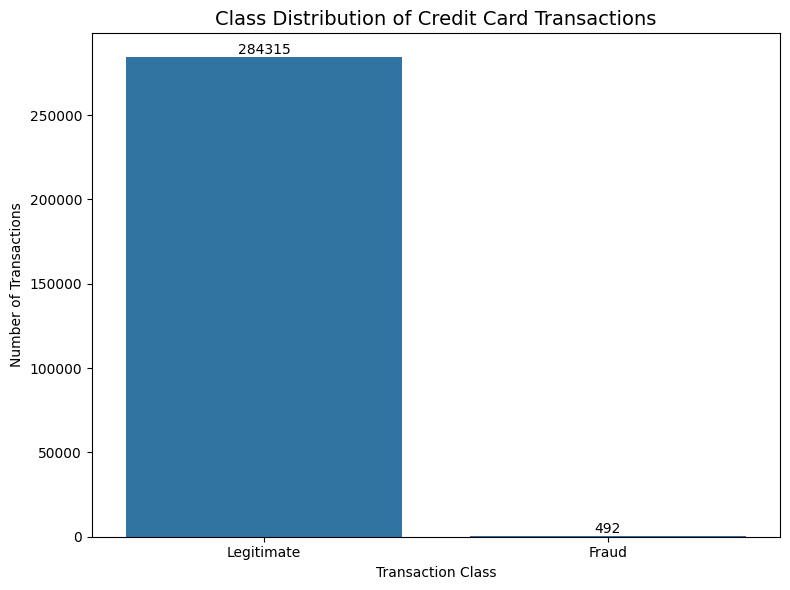


5. DESCRIPTIVE STATISTICS

Overall descriptive statistics:
              Time           V1           V2           V3           V4           V5           V6           V7           V8           V9          V10          V11          V12          V13          V14          V15          V16          V17          V18          V19          V20          V21          V22          V23          V24          V25          V26          V27          V28       Amount        Class
count  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000
mean    94813.8596       0.0000      -0.0000      -0.0000       0.0000       0.0000       0.0000      -0.0000       0.0000

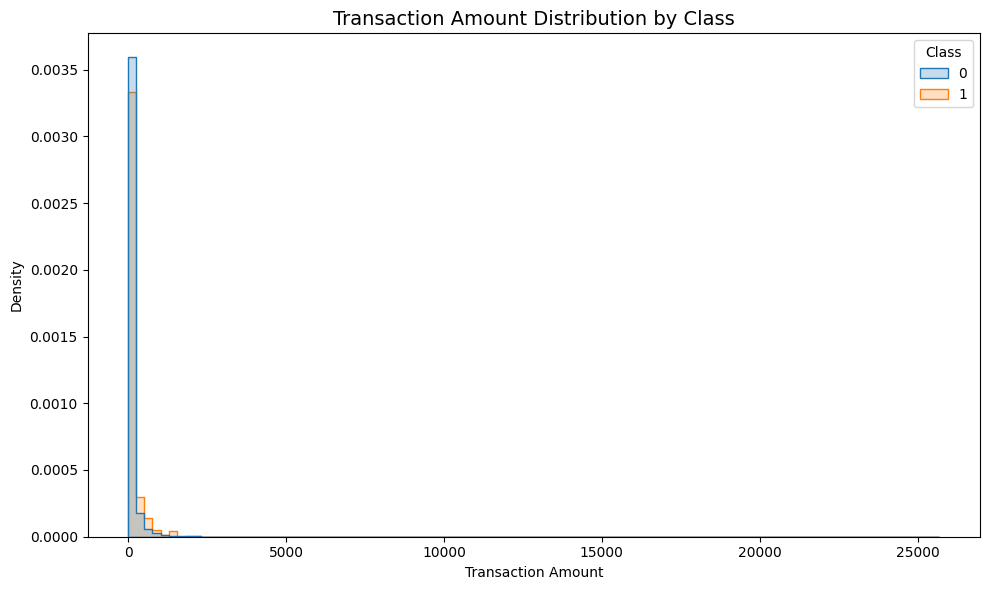


6. TIME-BASED ANALYSIS

Number of relative hour buckets: 48

Fraud rate by relative hour bucket:
             transactions  fraud_count  fraud_rate
hour_bucket                                       
0                    3963            2      0.0505
1                    2217            2      0.0902
2                    1576           21      1.3325
3                    1821           13      0.7139
4                    1082            6      0.5545
5                    1681           11      0.6544
6                    1831            3      0.1638
7                    3368           23      0.6829
8                    5179            5      0.0965
9                    7878           15      0.1904
10                   8288            2      0.0241
11                   8517           43      0.5049
12                   7732            9      0.1164
13                   7585            9      0.1187
14                   8029           13      0.1619
15                   7836          

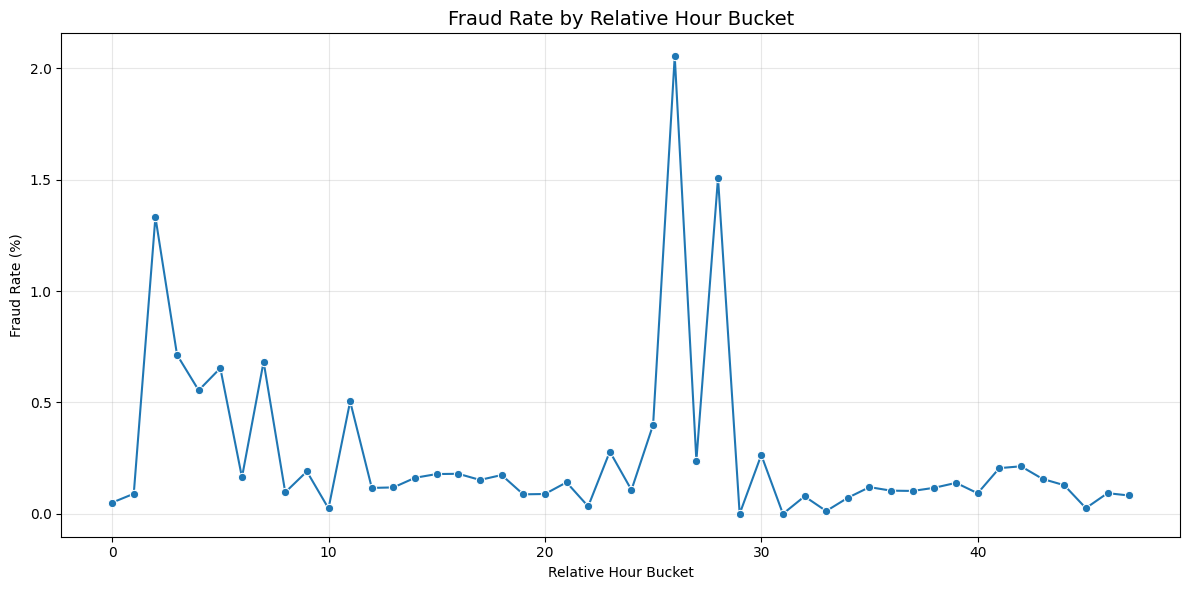


7. FEATURE–TARGET CORRELATION ANALYSIS

Feature correlations with Class:
Feature  Correlation
    V17    -0.326481
    V14    -0.302544
    V12    -0.260593
    V10    -0.216883
    V16    -0.196539
     V3    -0.192961
     V7    -0.187257
    V11     0.154876
     V4     0.133447
    V18    -0.111485
     V1    -0.101347
     V9    -0.097733
     V5    -0.094974
     V2     0.091289
     V6    -0.043643
    V21     0.040413
    V19     0.034783
    V20     0.020090
     V8     0.019875
    V27     0.017580
    V28     0.009536
    V24    -0.007221
    V13    -0.004570
    V26     0.004455
    V15    -0.004223
    V25     0.003308
    V23    -0.002685
    V22     0.000805

Generating Figure 4: Feature–Target Correlation...


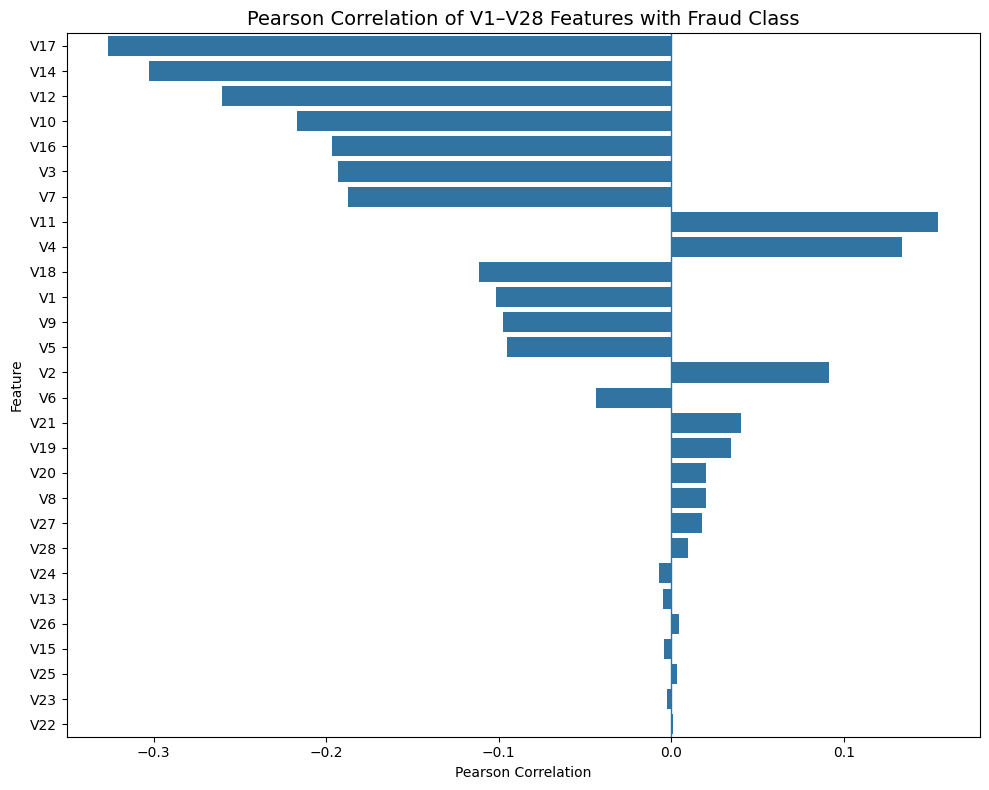


Top positively correlated features:
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
V20    0.020090
V8     0.019875
V27    0.017580
V28    0.009536
V26    0.004455

Top negatively correlated features:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733

8. SAVING EDA RESULTS
EDA CSV files saved successfully.

9. MANUSCRIPT-READY EDA SUMMARY

The dataset contains 284,807 transactions and
31 original variables, including the binary target variable
Class.

The dataset exhibits substantial class imbalance, with
284,315 legitimate transactions and
492 fraudulent transactions. Fraudulent
transactions represent 0.1727% of all observations,
corresponding to an approximate legitimate-to-fraud ratio
of 577.88:1.

No missing values were identified in the dataset, while
1,081 duplicate rows were detected.

The transaction Amount variable has a mean of
88.3496

In [2]:
# ============================================================
# STEP 1 OF 2 — EXPLORATORY DATA ANALYSIS (EDA)
# Credit Card Fraud Detection Dataset
# ============================================================

%matplotlib inline

from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_PATH = Path(
    "/kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv"
)

OUT_DIR = Path("/kaggle/working/eda_outputs")

# Remove previous EDA output to avoid stale files
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

V_COLS = [f"V{i}" for i in range(1, 29)]


# ============================================================
# 2. LOAD DATASET
# ============================================================

print("=" * 70)
print("CREDIT CARD FRAUD DETECTION — EDA")
print("=" * 70)

print("\nLoading dataset...")
print(f"Dataset path: {DATA_PATH}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")


# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("1. BASIC DATASET INFORMATION")
print("=" * 70)

print(f"\nNumber of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names:")
print(list(df.columns))

print("\nData types:")
print(df.dtypes)


# ============================================================
# 4. MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("2. MISSING VALUE ANALYSIS")
print("=" * 70)

missing_values = df.isnull().sum()
missing_total = missing_values.sum()

print(f"\nTotal missing values: {missing_total}")

if missing_total == 0:
    print("No missing values found.")
else:
    missing_df = (
        missing_values[missing_values > 0]
        .sort_values(ascending=False)
        .to_frame("missing_count")
    )

    print("\nColumns containing missing values:")
    print(missing_df)


# ============================================================
# 5. DUPLICATE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("3. DUPLICATE ANALYSIS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(f"\nDuplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_percentage:.4f}%")


# ============================================================
# 6. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("4. CLASS DISTRIBUTION")
print("=" * 70)

class_counts = (
    df["Class"]
    .value_counts()
    .sort_index()
)

class_names = {
    0: "Legitimate",
    1: "Fraud"
}

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Class_Name": [
        class_names.get(
            value,
            str(value)
        )
        for value in class_counts.index
    ],
    "Count": class_counts.values
})

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / len(df)
    * 100
)

print("\nClass distribution:")
print(
    class_distribution.to_string(
        index=False
    )
)

legitimate_count = int(
    class_counts.get(0, 0)
)

fraud_count = int(
    class_counts.get(1, 0)
)

fraud_rate = (
    fraud_count / len(df) * 100
)

imbalance_ratio = (
    legitimate_count / fraud_count
    if fraud_count > 0
    else np.inf
)

print(f"\nLegitimate transactions: {legitimate_count:,}")
print(f"Fraudulent transactions: {fraud_count:,}")
print(f"Fraud rate: {fraud_rate:.4f}%")
print(
    f"Class imbalance ratio "
    f"(legitimate:fraud): {imbalance_ratio:.2f}:1"
)


# ============================================================
# 7. GRAPH 1 — CLASS BALANCE
# ============================================================

print("\nGenerating Figure 1: Class Balance...")

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=class_distribution,
    x="Class_Name",
    y="Count"
)

plt.title(
    "Class Distribution of Credit Card Transactions",
    fontsize=14
)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f"
    )

plt.tight_layout()

plt.savefig(
    OUT_DIR / "class_balance.png",
    dpi=300,
    bbox_inches="tight"
)

# SHOW IMAGE DIRECTLY IN KAGGLE OUTPUT
plt.show()

plt.close()


# ============================================================
# 8. DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("5. DESCRIPTIVE STATISTICS")
print("=" * 70)

print("\nOverall descriptive statistics:")

print(
    df.describe()
    .round(4)
    .to_string()
)


# ============================================================
# 9. AMOUNT STATISTICS BY CLASS
# ============================================================

print("\nAmount statistics by transaction class:")

amount_stats = (
    df.groupby("Class")["Amount"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
)

amount_stats["Class_Name"] = (
    amount_stats.index.map(class_names)
)

amount_stats = amount_stats[
    [
        "Class_Name",
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ]
]

print(
    amount_stats
    .round(4)
    .to_string()
)


# ============================================================
# 10. TIME STATISTICS BY CLASS
# ============================================================

print("\nTime statistics by transaction class:")

time_stats = (
    df.groupby("Class")["Time"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
)

time_stats["Class_Name"] = (
    time_stats.index.map(class_names)
)

time_stats = time_stats[
    [
        "Class_Name",
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ]
]

print(
    time_stats
    .round(4)
    .to_string()
)


# ============================================================
# 11. GRAPH 2 — AMOUNT DISTRIBUTION
# ============================================================

print("\nGenerating Figure 2: Transaction Amount Distribution...")

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(
    "Transaction Amount Distribution by Class",
    fontsize=14
)

plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.tight_layout()

plt.savefig(
    OUT_DIR / "amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# SHOW IMAGE DIRECTLY IN KAGGLE OUTPUT
plt.show()

plt.close()


# ============================================================
# 12. TIME → RELATIVE HOUR BUCKET
# ============================================================

print("\n" + "=" * 70)
print("6. TIME-BASED ANALYSIS")
print("=" * 70)

df["hour_bucket"] = (
    df["Time"] // 3600
).astype(int)

print(
    f"\nNumber of relative hour buckets: "
    f"{df['hour_bucket'].nunique()}"
)


# ============================================================
# 13. FRAUD RATE BY HOUR BUCKET
# ============================================================

hourly_stats = (
    df.groupby("hour_bucket")
    .agg(
        transactions=("Class", "count"),
        fraud_count=("Class", "sum")
    )
)

hourly_stats["fraud_rate"] = (
    hourly_stats["fraud_count"]
    / hourly_stats["transactions"]
    * 100
)

print("\nFraud rate by relative hour bucket:")

print(
    hourly_stats
    .round(4)
    .to_string()
)


# ============================================================
# 14. GRAPH 3 — FRAUD RATE BY HOUR
# ============================================================

print(
    "\nGenerating Figure 3: "
    "Fraud Rate by Relative Hour Bucket..."
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_stats,
    x=hourly_stats.index,
    y="fraud_rate",
    marker="o"
)

plt.title(
    "Fraud Rate by Relative Hour Bucket",
    fontsize=14
)

plt.xlabel("Relative Hour Bucket")
plt.ylabel("Fraud Rate (%)")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUT_DIR / "fraud_rate_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

# SHOW IMAGE DIRECTLY IN KAGGLE OUTPUT
plt.show()

plt.close()


# ============================================================
# 15. FEATURE–TARGET CORRELATION
# ============================================================

print("\n" + "=" * 70)
print("7. FEATURE–TARGET CORRELATION ANALYSIS")
print("=" * 70)

correlations = (
    df[V_COLS + ["Class"]]
    .corr()["Class"]
    .drop("Class")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

correlation_df = correlations.reset_index()

correlation_df.columns = [
    "Feature",
    "Correlation"
]

print("\nFeature correlations with Class:")

print(
    correlation_df
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 16. GRAPH 4 — FEATURE/TARGET CORRELATION
# ============================================================

print(
    "\nGenerating Figure 4: "
    "Feature–Target Correlation..."
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=correlation_df,
    x="Correlation",
    y="Feature"
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Pearson Correlation of V1–V28 Features with Fraud Class",
    fontsize=14
)

plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    OUT_DIR / "feature_class_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

# SHOW IMAGE DIRECTLY IN KAGGLE OUTPUT
plt.show()

plt.close()


# ============================================================
# 17. TOP CORRELATED FEATURES
# ============================================================

print("\nTop positively correlated features:")

positive_corr = (
    correlations
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(
    positive_corr
    .round(6)
    .to_string()
)

print("\nTop negatively correlated features:")

negative_corr = (
    correlations
    .sort_values(
        ascending=True
    )
    .head(10)
)

print(
    negative_corr
    .round(6)
    .to_string()
)


# ============================================================
# 18. SAVE EDA RESULTS
# ============================================================

print("\n" + "=" * 70)
print("8. SAVING EDA RESULTS")
print("=" * 70)

# Dataset summary
summary = {
    "dataset_rows": len(df),
    "original_dataset_columns": 31,
    "missing_values": int(missing_total),
    "duplicate_rows": int(duplicate_count),
    "legitimate_transactions": legitimate_count,
    "fraudulent_transactions": fraud_count,
    "fraud_rate_percent": fraud_rate,
    "imbalance_ratio_legitimate_to_fraud": imbalance_ratio,
    "amount_mean": df["Amount"].mean(),
    "amount_median": df["Amount"].median(),
    "amount_std": df["Amount"].std(),
    "amount_min": df["Amount"].min(),
    "amount_max": df["Amount"].max(),
    "time_min": df["Time"].min(),
    "time_max": df["Time"].max()
}

summary_df = pd.DataFrame([summary])

summary_df.to_csv(
    OUT_DIR / "dataset_summary.csv",
    index=False
)

class_distribution.to_csv(
    OUT_DIR / "class_distribution.csv",
    index=False
)

correlation_df.to_csv(
    OUT_DIR / "feature_class_correlations.csv",
    index=False
)

hourly_stats.to_csv(
    OUT_DIR / "fraud_rate_by_hour.csv"
)

print("EDA CSV files saved successfully.")


# ============================================================
# 19. MANUSCRIPT-READY SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("9. MANUSCRIPT-READY EDA SUMMARY")
print("=" * 70)

print(
    f"""
The dataset contains {len(df):,} transactions and
31 original variables, including the binary target variable
Class.

The dataset exhibits substantial class imbalance, with
{legitimate_count:,} legitimate transactions and
{fraud_count:,} fraudulent transactions. Fraudulent
transactions represent {fraud_rate:.4f}% of all observations,
corresponding to an approximate legitimate-to-fraud ratio
of {imbalance_ratio:.2f}:1.

No missing values were identified in the dataset, while
{duplicate_count:,} duplicate rows were detected.

The transaction Amount variable has a mean of
{df["Amount"].mean():.4f}, a median of
{df["Amount"].median():.4f}, and a standard deviation of
{df["Amount"].std():.4f}.

Pearson correlation analysis between the anonymized V1–V28
features and the binary Class target was performed to
characterize linear feature-target associations.

The Time feature was additionally transformed into relative
hour buckets to examine temporal variation in the observed
fraud rate.

These findings highlight the highly imbalanced nature of the
fraud detection problem and motivate the use of appropriate
class-imbalance-aware machine learning and evaluation
strategies in the subsequent modeling stage.
"""
)


# ============================================================
# 20. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nFigures were displayed directly in the Kaggle output.")

print("\nFigures were also saved to:")
print(OUT_DIR)

print("\nGenerated figures:")

for file_path in sorted(OUT_DIR.glob("*.png")):
    print(f"  - {file_path.name}")

print("\nGenerated CSV files:")

for file_path in sorted(OUT_DIR.glob("*.csv")):
    print(f"  - {file_path.name}")

print("\n" + "=" * 70)

STEP 2 OF 2 — EMPIRICAL MODEL VALIDATION

Loading dataset...
Dataset: /kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv

Dataset shape: (284807, 31)
Transactions: 284,807
Fraud transactions: 492
Fraud rate: 0.1727%

TRAIN / TEST SPLIT

Training samples: 199,364
Test samples: 85,443
Training fraud cases: 344
Test fraud cases: 148

FEATURE ENGINEERING — EQ. (1)

Engineering a(x), b(x), c(x), f(x)...

Generated signals:
['a_anomaly', 'b_behavioural', 'c_rule', 'f_freq_severity', 'recon_error']

Signal summary:
         a_anomaly  b_behavioural       c_rule  f_freq_severity  recon_error
count  284807.0000    284807.0000  284807.0000      284807.0000  284807.0000
mean        0.1411         0.0152       0.0832           0.2138       0.6403
std         0.1063         0.0135       0.2762           0.0671       1.5483
min         0.0000         0.0000       0.0000           0.0000       0.0526
25%         0.0678         0.0090       0.0000           0.2018       0.2949
50%  

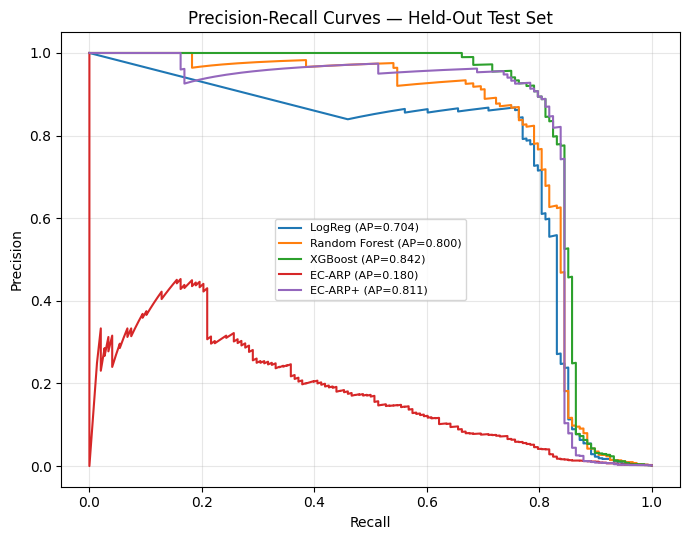


Generating Figure 2: ROC Curves...


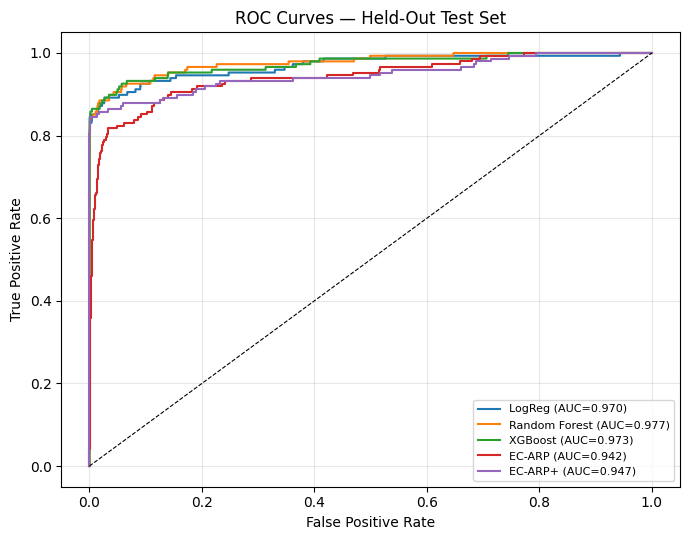


Generating Figure 3: EC-ARP+ Calibrated Weights...


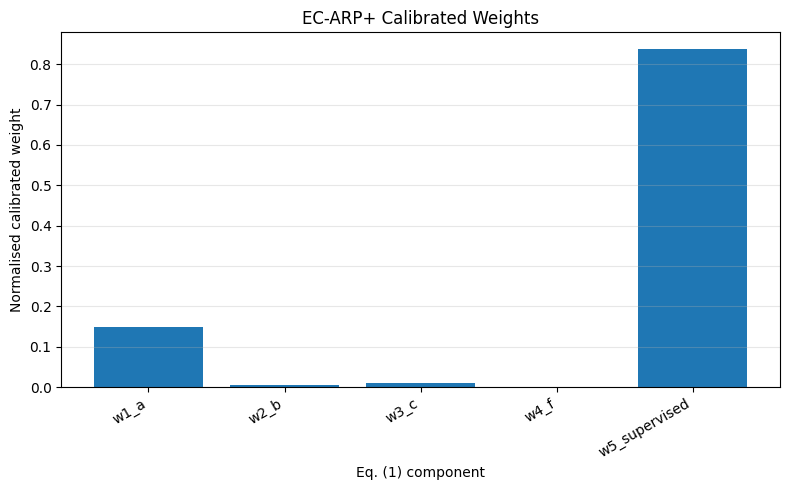


Generating Figure 4: PR-AUC Model Comparison...


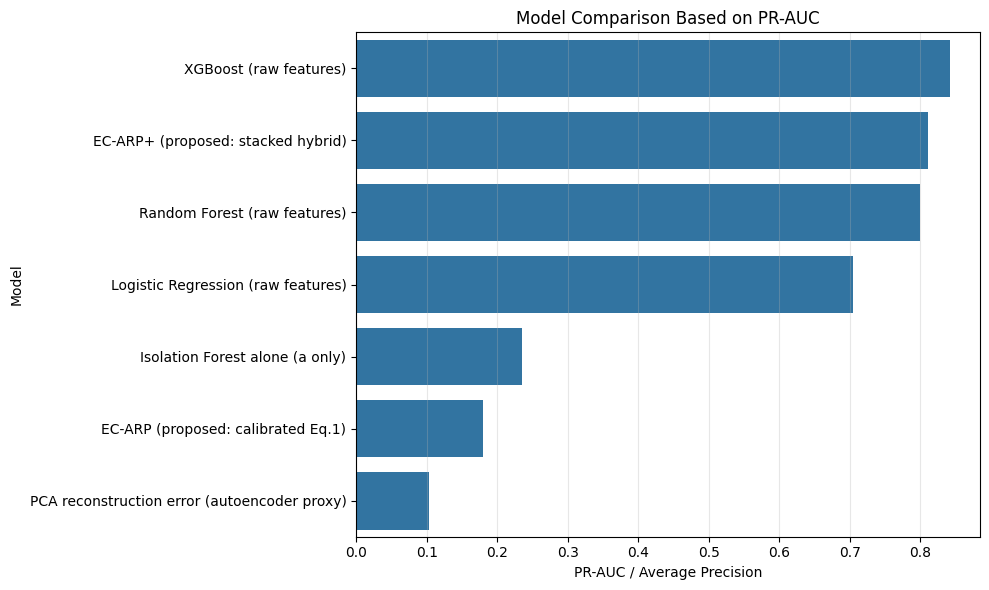


STEP 2 COMPLETED SUCCESSFULLY

Total runtime: 170.2 seconds

Results saved to:
/kaggle/working/model_outputs

Generated files:
  - calibrated_weights.json
  - calibrated_weights.png
  - model_comparison.csv
  - pr_auc_comparison.png
  - pr_curves.png
  - roc_curves.png
  - run_metadata.json

LIMITATIONS

1. The ULB dataset does not contain customer/entity identifiers.
   Therefore, the behavioural-deviation and frequency signals
   are dataset-level proxies rather than true per-account
   longitudinal behavioural profiles.

2. V1-V28 are PCA-anonymised features. Consequently, individual
   feature-level business interpretation is limited.

3. The c(x_r) control rule uses a large-amount threshold and a
   relative-time off-hours proxy. These are operational rules
   designed for reproducibility and should not be interpreted
   as universal fraud rules.

4. Results are based on one stratified 70/30 train-test split
   with RANDOM_STATE=42. They should therefore be interpreted
   as empi

In [1]:
# ============================================================
# STEP 2 OF 2
# EMPIRICAL VALIDATION OF AI-ASSISTED RED-FLAG PRIORITISATION
#
# Eq. (1):
# s(r) = w1*a(x_r) + w2*b(x_r) + w3*c(x_r) + w4*f(x_r)
#
# EC-ARP  : Empirically-Calibrated AI-assisted Red-flag Prioritisation
# EC-ARP+ : EC-ARP + supervised XGBoost stacking signal
# ============================================================

from pathlib import Path
import json
import time
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest
)

from sklearn.cluster import MiniBatchKMeans

from sklearn.decomposition import PCA

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
)

import xgboost as xgb


# ============================================================
# 1. CONFIGURATION
# ============================================================

RANDOM_STATE = 42

DATA_PATH = Path(
    "/kaggle/input/datasets/alamintokdershoukhin/creditcard/creditcard.csv"
)

RESULTS_DIR = Path(
    "/kaggle/working/model_outputs"
)

# Remove previous results to avoid stale files
if RESULTS_DIR.exists():
    shutil.rmtree(RESULTS_DIR)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

V_COLS = [
    f"V{i}"
    for i in range(1, 29)
]


# ============================================================
# 2. DATA LOADING
# ============================================================

def load_data():

    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Dataset not found at:\n{DATA_PATH}"
        )

    df = pd.read_csv(DATA_PATH)

    df["Class"] = (
        df["Class"]
        .astype(int)
    )

    if "Time" not in df.columns:
        raise ValueError(
            "The dataset must contain a 'Time' column."
        )

    return df


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

def engineer_signals(
    df,
    fit_on_idx
):
    """
    Compute the four components of Eq. (1):

        a(x_r) = anomaly score
        b(x_r) = behavioural-deviation score
        c(x_r) = control-rule violation
        f(x_r) = frequency/severity score

    Unsupervised components are fitted only on the training
    portion and then applied to the complete dataset.
    """

    out = pd.DataFrame(
        index=df.index
    )

    V = df[V_COLS].values

    # --------------------------------------------------------
    # Standardise V1-V28
    # --------------------------------------------------------

    scaler_V = StandardScaler().fit(
        V[fit_on_idx]
    )

    Vs = scaler_V.transform(V)


    # ========================================================
    # a(x_r): ISOLATION FOREST ANOMALY SCORE
    # ========================================================

    iso = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    iso.fit(
        Vs[fit_on_idx]
    )

    # Isolation Forest score_samples:
    # lower = more anomalous
    #
    # Negate so that:
    # higher = more anomalous

    raw_a = -iso.score_samples(Vs)

    a_scaler = MinMaxScaler().fit(
        raw_a[fit_on_idx]
        .reshape(-1, 1)
    )

    out["a_anomaly"] = (
        a_scaler
        .transform(
            raw_a.reshape(-1, 1)
        )
        .ravel()
    )


    # ========================================================
    # b(x_r): BEHAVIOURAL-DEVIATION SCORE
    # ========================================================

    kmeans = MiniBatchKMeans(
        n_clusters=12,
        random_state=RANDOM_STATE,
        n_init=10,
        batch_size=2048
    )

    kmeans.fit(
        Vs[fit_on_idx]
    )

    centroids = (
        kmeans.cluster_centers_
    )

    labels = kmeans.predict(
        Vs
    )

    dist = np.linalg.norm(
        Vs - centroids[labels],
        axis=1
    )

    b_scaler = MinMaxScaler().fit(
        dist[fit_on_idx]
        .reshape(-1, 1)
    )

    out["b_behavioural"] = (
        b_scaler
        .transform(
            dist.reshape(-1, 1)
        )
        .ravel()
    )


    # ========================================================
    # c(x_r): CONTROL-RULE VIOLATION
    # ========================================================

    # 99th percentile amount threshold
    amount_hi = np.percentile(
        df["Amount"].values[fit_on_idx],
        99
    )

    # IMPORTANT:
    # Time is elapsed seconds, not actual wall-clock time.
    # This creates a relative time bucket.
    hour_bucket = (
        df["Time"].values // 3600
    ).astype(int)

    # Use first 5 relative hours as the off-hours proxy
    off_hours = (
        hour_bucket % 24 < 5
    )

    large_amount = (
        df["Amount"].values
        > amount_hi
    )

    out["c_rule"] = (
        off_hours | large_amount
    ).astype(float)


    # ========================================================
    # f(x_r): FREQUENCY / SEVERITY
    # ========================================================

    # --------------------------------------------------------
    # Transaction severity
    # --------------------------------------------------------

    amt_scaler = MinMaxScaler().fit(
        df["Amount"]
        .values[fit_on_idx]
        .reshape(-1, 1)
    )

    severity = (
        amt_scaler
        .transform(
            df["Amount"]
            .values
            .reshape(-1, 1)
        )
        .ravel()
    )


    # --------------------------------------------------------
    # Local transaction density
    # +/- 60 seconds
    # --------------------------------------------------------

    time_values = (
        df["Time"]
        .values
    )

    time_sorted_idx = np.argsort(
        time_values
    )

    t_sorted = (
        time_values[
            time_sorted_idx
        ]
    )

    window = 60.0

    left = np.searchsorted(
        t_sorted,
        t_sorted - window,
        side="left"
    )

    right = np.searchsorted(
        t_sorted,
        t_sorted + window,
        side="right"
    )

    density_sorted = (
        right - left
    ).astype(float)

    density = np.empty_like(
        density_sorted
    )

    density[
        time_sorted_idx
    ] = density_sorted


    dens_scaler = MinMaxScaler().fit(
        density[fit_on_idx]
        .reshape(-1, 1)
    )

    density_n = (
        dens_scaler
        .transform(
            density.reshape(-1, 1)
        )
        .ravel()
    )

    out["f_freq_severity"] = (
        0.5 * severity
        + 0.5 * density_n
    )


    # ========================================================
    # PCA RECONSTRUCTION ERROR
    # ========================================================
    #
    # Used only as a standalone baseline.
    #
    # It is NOT included in EC-ARP / EC-ARP+.

    pca = PCA(
        n_components=10,
        random_state=RANDOM_STATE
    )

    pca.fit(
        Vs[fit_on_idx]
    )

    reconstructed = (
        pca.inverse_transform(
            pca.transform(Vs)
        )
    )

    recon_error = np.mean(
        (Vs - reconstructed) ** 2,
        axis=1
    )

    out["recon_error"] = (
        recon_error
    )

    return out


# ============================================================
# 4. TOP-K METRICS
# ============================================================

def topk_precision_recall(
    y_true,
    scores,
    frac=0.01
):

    y_true = np.asarray(
        y_true
    )

    scores = np.asarray(
        scores
    )

    n = len(y_true)

    k = max(
        1,
        int(
            np.ceil(
                n * frac
            )
        )
    )

    order = np.argsort(
        -scores
    )

    top_indices = (
        order[:k]
    )

    tp = (
        y_true[
            top_indices
        ].sum()
    )

    precision = (
        tp / k
    )

    total_positive = (
        y_true.sum()
    )

    recall = (
        tp / total_positive
        if total_positive > 0
        else 0.0
    )

    return (
        precision,
        recall,
        k,
        int(tp)
    )


# ============================================================
# 5. MODEL EVALUATION
# ============================================================

def evaluate_probability_model(
    name,
    y_true,
    scores
):

    y_true = np.asarray(
        y_true
    )

    scores = np.asarray(
        scores
    )

    predictions = (
        scores >= 0.5
    ).astype(int)

    precision_1pct, recall_1pct, k, tp = (
        topk_precision_recall(
            y_true,
            scores,
            frac=0.01
        )
    )

    return {
        "model": name,

        "roc_auc": roc_auc_score(
            y_true,
            scores
        ),

        "pr_auc": average_precision_score(
            y_true,
            scores
        ),

        "f1_at_0.5": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "precision_at_0.5": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall_at_0.5": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "precision_at_top1pct": precision_1pct,

        "recall_at_top1pct": recall_1pct,

        "top1pct_k": k,

        "top1pct_true_positives": tp
    }


# ============================================================
# 6. ANOMALY MODEL EVALUATION
# ============================================================

def evaluate_anomaly_model(
    name,
    y_true,
    scores
):

    y_true = np.asarray(
        y_true
    )

    scores = np.asarray(
        scores
    )

    precision_1pct, recall_1pct, k, tp = (
        topk_precision_recall(
            y_true,
            scores,
            frac=0.01
        )
    )

    return {
        "model": name,

        "roc_auc": roc_auc_score(
            y_true,
            scores
        ),

        "pr_auc": average_precision_score(
            y_true,
            scores
        ),

        # Not reported as "at 0.5" because
        # anomaly scores are not probabilities.
        "f1_at_0.5": np.nan,

        "precision_at_0.5": np.nan,

        "recall_at_0.5": np.nan,

        "precision_at_top1pct": precision_1pct,

        "recall_at_top1pct": recall_1pct,

        "top1pct_k": k,

        "top1pct_true_positives": tp
    }


# ============================================================
# 7. MAIN
# ============================================================

def main():

    start_time = time.time()

    print("=" * 75)
    print("STEP 2 OF 2 — EMPIRICAL MODEL VALIDATION")
    print("=" * 75)

    print("\nLoading dataset...")
    print(f"Dataset: {DATA_PATH}")

    df = load_data()

    df = df.reset_index(
        drop=True
    )

    n = len(df)

    n_fraud = int(
        df["Class"].sum()
    )

    fraud_rate = (
        100 * n_fraud / n
    )

    print(
        f"\nDataset shape: {df.shape}"
    )

    print(
        f"Transactions: {n:,}"
    )

    print(
        f"Fraud transactions: {n_fraud:,}"
    )

    print(
        f"Fraud rate: {fraud_rate:.4f}%"
    )


    # ========================================================
    # TRAIN / TEST SPLIT
    # ========================================================

    print("\n" + "=" * 75)
    print("TRAIN / TEST SPLIT")
    print("=" * 75)

    indices = np.arange(
        n
    )

    (
        train_idx,
        test_idx,
        y_train,
        y_test
    ) = train_test_split(
        indices,
        df["Class"].values,
        test_size=0.30,
        stratify=df["Class"].values,
        random_state=RANDOM_STATE
    )

    print(
        f"\nTraining samples: {len(train_idx):,}"
    )

    print(
        f"Test samples: {len(test_idx):,}"
    )

    print(
        f"Training fraud cases: {int(y_train.sum()):,}"
    )

    print(
        f"Test fraud cases: {int(y_test.sum()):,}"
    )


    # ========================================================
    # FEATURE ENGINEERING
    # ========================================================

    print("\n" + "=" * 75)
    print("FEATURE ENGINEERING — EQ. (1)")
    print("=" * 75)

    print(
        "\nEngineering a(x), b(x), c(x), f(x)..."
    )

    signals = engineer_signals(
        df,
        train_idx
    )

    print(
        "\nGenerated signals:"
    )

    print(
        signals.columns.tolist()
    )

    print(
        "\nSignal summary:"
    )

    print(
        signals.describe()
        .round(4)
        .to_string()
    )


    # ========================================================
    # RAW FEATURES
    # ========================================================

    X_raw = (
        df[
            V_COLS + ["Amount"]
        ]
        .values
    )

    X_raw_train = (
        X_raw[train_idx]
    )

    X_raw_test = (
        X_raw[test_idx]
    )

    scaler_raw = (
        StandardScaler()
        .fit(X_raw_train)
    )

    X_raw_train_s = (
        scaler_raw
        .transform(X_raw_train)
    )

    X_raw_test_s = (
        scaler_raw
        .transform(X_raw_test)
    )


    # ========================================================
    # RESULTS
    # ========================================================

    results = []


    # ========================================================
    # BASELINE 1 — LOGISTIC REGRESSION
    # ========================================================

    print("\n" + "=" * 75)
    print("BASELINE 1 — LOGISTIC REGRESSION")
    print("=" * 75)

    print(
        "\nTraining Logistic Regression..."
    )

    lr = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    lr.fit(
        X_raw_train_s,
        y_train
    )

    lr_test_scores = (
        lr.predict_proba(
            X_raw_test_s
        )[:, 1]
    )

    results.append(
        evaluate_probability_model(
            "Logistic Regression (raw features)",
            y_test,
            lr_test_scores
        )
    )

    print("Completed.")


    # ========================================================
    # BASELINE 2 — RANDOM FOREST
    # ========================================================

    print("\n" + "=" * 75)
    print("BASELINE 2 — RANDOM FOREST")
    print("=" * 75)

    print(
        "\nTraining Random Forest..."
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf.fit(
        X_raw_train,
        y_train
    )

    rf_test_scores = (
        rf.predict_proba(
            X_raw_test
        )[:, 1]
    )

    results.append(
        evaluate_probability_model(
            "Random Forest (raw features)",
            y_test,
            rf_test_scores
        )
    )

    print("Completed.")


    # ========================================================
    # BASELINE 3 — XGBOOST
    # ========================================================

    print("\n" + "=" * 75)
    print("BASELINE 3 — XGBOOST")
    print("=" * 75)

    print(
        "\nTraining XGBoost..."
    )

    scale_pos_weight = (
        (len(y_train) - y_train.sum())
        / y_train.sum()
    )

    xgb_clf = xgb.XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb_clf.fit(
        X_raw_train,
        y_train
    )

    xgb_test_scores = (
        xgb_clf.predict_proba(
            X_raw_test
        )[:, 1]
    )

    results.append(
        evaluate_probability_model(
            "XGBoost (raw features)",
            y_test,
            xgb_test_scores
        )
    )

    print("Completed.")


    # ========================================================
    # BASELINE 4 — ISOLATION FOREST
    # ========================================================

    print("\n" + "=" * 75)
    print("BASELINE 4 — ISOLATION FOREST")
    print("=" * 75)

    print(
        "\nEvaluating Isolation Forest..."
    )

    iso_scores = (
        signals[
            "a_anomaly"
        ]
        .values[
            test_idx
        ]
    )

    results.append(
        evaluate_anomaly_model(
            "Isolation Forest alone (a only)",
            y_test,
            iso_scores
        )
    )

    print("Completed.")


    # ========================================================
    # BASELINE 5 — PCA RECONSTRUCTION
    # ========================================================

    print("\n" + "=" * 75)
    print("BASELINE 5 — PCA RECONSTRUCTION ERROR")
    print("=" * 75)

    print(
        "\nEvaluating PCA reconstruction error..."
    )

    pca_scores = (
        signals[
            "recon_error"
        ]
        .values[
            test_idx
        ]
    )

    results.append(
        evaluate_anomaly_model(
            "PCA reconstruction error (autoencoder proxy)",
            y_test,
            pca_scores
        )
    )

    print("Completed.")


    # ========================================================
    # EC-ARP
    # ========================================================

    print("\n" + "=" * 75)
    print("PROPOSED MODEL — EC-ARP")
    print("=" * 75)

    print(
        "\nTraining empirically calibrated Eq. (1) model..."
    )

    meta_cols = [
        "a_anomaly",
        "b_behavioural",
        "c_rule",
        "f_freq_severity"
    ]

    Xm_train = (
        signals
        .loc[
            train_idx,
            meta_cols
        ]
        .values
    )

    Xm_test = (
        signals
        .loc[
            test_idx,
            meta_cols
        ]
        .values
    )

    meta_ecarp = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    meta_ecarp.fit(
        Xm_train,
        y_train
    )

    ecarp_scores = (
        meta_ecarp
        .predict_proba(
            Xm_test
        )[:, 1]
    )

    results.append(
        evaluate_probability_model(
            "EC-ARP (proposed: calibrated Eq.1)",
            y_test,
            ecarp_scores
        )
    )


    # ========================================================
    # EC-ARP WEIGHTS
    # ========================================================

    raw_weights = (
        meta_ecarp
        .coef_
        .ravel()
    )

    positive_weights = np.clip(
        raw_weights,
        0,
        None
    )

    if positive_weights.sum() > 0:

        normalized_weights = (
            positive_weights
            / positive_weights.sum()
        )

    else:

        normalized_weights = (
            np.ones(
                len(positive_weights)
            )
            / len(positive_weights)
        )

    calibrated_weights = dict(
        zip(
            [
                "w1_a",
                "w2_b",
                "w3_c",
                "w4_f"
            ],
            normalized_weights.tolist()
        )
    )

    print(
        "\nEC-ARP calibrated weights:"
    )

    for key, value in calibrated_weights.items():

        print(
            f"  {key}: {value:.6f}"
        )


    # ========================================================
    # EC-ARP+
    # ========================================================

    print("\n" + "=" * 75)
    print("PROPOSED MODEL — EC-ARP+")
    print("=" * 75)

    print(
        "\nGenerating out-of-fold XGBoost predictions..."
    )

    oof_predictions = np.zeros(
        len(train_idx)
    )

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    for fold_number, (
        fold_train,
        fold_valid
    ) in enumerate(
        skf.split(
            X_raw_train,
            y_train
        ),
        start=1
    ):

        print(
            f"  Training OOF fold {fold_number}/5..."
        )

        fold_model = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        fold_model.fit(
            X_raw_train[
                fold_train
            ],
            y_train[
                fold_train
            ]
        )

        oof_predictions[
            fold_valid
        ] = (
            fold_model
            .predict_proba(
                X_raw_train[
                    fold_valid
                ]
            )[:, 1]
        )


    print(
        "\nTraining EC-ARP+ meta-learner..."
    )

    Xm_train_plus = np.column_stack(
        [
            Xm_train,
            oof_predictions
        ]
    )

    Xm_test_plus = np.column_stack(
        [
            Xm_test,
            xgb_test_scores
        ]
    )

    meta_plus = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    meta_plus.fit(
        Xm_train_plus,
        y_train
    )

    ecarp_plus_scores = (
        meta_plus
        .predict_proba(
            Xm_test_plus
        )[:, 1]
    )

    results.append(
        evaluate_probability_model(
            "EC-ARP+ (proposed: stacked hybrid)",
            y_test,
            ecarp_plus_scores
        )
    )


    # ========================================================
    # EC-ARP+ WEIGHTS
    # ========================================================

    raw_weights_plus = (
        meta_plus
        .coef_
        .ravel()
    )

    positive_weights_plus = np.clip(
        raw_weights_plus,
        0,
        None
    )

    if positive_weights_plus.sum() > 0:

        normalized_weights_plus = (
            positive_weights_plus
            / positive_weights_plus.sum()
        )

    else:

        normalized_weights_plus = (
            np.ones(
                len(positive_weights_plus)
            )
            / len(positive_weights_plus)
        )

    calibrated_weights_plus = dict(
        zip(
            [
                "w1_a",
                "w2_b",
                "w3_c",
                "w4_f",
                "w5_supervised"
            ],
            normalized_weights_plus.tolist()
        )
    )

    print(
        "\nEC-ARP+ calibrated weights:"
    )

    for key, value in calibrated_weights_plus.items():

        print(
            f"  {key}: {value:.6f}"
        )


    # ========================================================
    # MODEL COMPARISON
    # ========================================================

    results_df = pd.DataFrame(
        results
    )

    results_df = (
        results_df
        .sort_values(
            "pr_auc",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    # ========================================================
    # SAVE MODEL RESULTS
    # ========================================================

    results_df.to_csv(
        RESULTS_DIR
        / "model_comparison.csv",
        index=False
    )

    with open(
        RESULTS_DIR
        / "calibrated_weights.json",
        "w"
    ) as file:

        json.dump(
            {
                "EC-ARP":
                    calibrated_weights,

                "EC-ARP+":
                    calibrated_weights_plus
            },
            file,
            indent=2
        )


    metadata = {

        "n_transactions":
            int(n),

        "n_fraud":
            int(n_fraud),

        "fraud_rate_pct":
            fraud_rate,

        "train_size":
            int(len(train_idx)),

        "test_size":
            int(len(test_idx)),

        "random_state":
            RANDOM_STATE,

        "runtime_seconds":
            time.time() - start_time,

        "dataset":
            "ULB Credit Card Fraud Detection "
            "(Dal Pozzolo et al., 2015, "
            "doi:10.1109/SSCI.2015.33)"
    }

    with open(
        RESULTS_DIR
        / "run_metadata.json",
        "w"
    ) as file:

        json.dump(
            metadata,
            file,
            indent=2
        )


    # ========================================================
    # PRINT MODEL COMPARISON
    # ========================================================

    print("\n" + "=" * 75)
    print("MODEL COMPARISON — HELD-OUT TEST SET")
    print("=" * 75)

    display_df = (
        results_df[
            [
                "model",
                "roc_auc",
                "pr_auc",
                "f1_at_0.5",
                "precision_at_0.5",
                "recall_at_0.5",
                "precision_at_top1pct",
                "recall_at_top1pct"
            ]
        ]
        .copy()
    )

    numeric_columns = (
        display_df
        .select_dtypes(
            include=np.number
        )
        .columns
    )

    display_df[
        numeric_columns
    ] = display_df[
        numeric_columns
    ].round(4)

    print(
        display_df.to_string(
            index=False
        )
    )


    # ========================================================
    # TOP 1% INVESTIGATION CAPACITY
    # ========================================================

    print("\n" + "=" * 75)
    print("TOP 1% INVESTIGATION PRIORITISATION")
    print("=" * 75)

    top1_df = (
        results_df[
            [
                "model",
                "precision_at_top1pct",
                "recall_at_top1pct",
                "top1pct_k",
                "top1pct_true_positives"
            ]
        ]
        .copy()
    )

    top1_df[
        [
            "precision_at_top1pct",
            "recall_at_top1pct"
        ]
    ] = (
        top1_df[
            [
                "precision_at_top1pct",
                "recall_at_top1pct"
            ]
        ]
        .round(4)
    )

    print(
        top1_df.to_string(
            index=False
        )
    )


    # ========================================================
    # FIGURE 1 — PRECISION-RECALL CURVES
    # ========================================================

    print("\nGenerating Figure 1: Precision-Recall Curves...")

    curve_models = [

        (
            "LogReg",
            lr_test_scores
        ),

        (
            "Random Forest",
            rf_test_scores
        ),

        (
            "XGBoost",
            xgb_test_scores
        ),

        (
            "EC-ARP",
            ecarp_scores
        ),

        (
            "EC-ARP+",
            ecarp_plus_scores
        )
    ]

    plt.figure(
        figsize=(7, 5.5)
    )

    for name, scores in curve_models:

        precision, recall, _ = (
            precision_recall_curve(
                y_test,
                scores
            )
        )

        ap = (
            average_precision_score(
                y_test,
                scores
            )
        )

        plt.plot(
            recall,
            precision,
            label=f"{name} (AP={ap:.3f})"
        )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        "Precision-Recall Curves — Held-Out Test Set"
    )

    plt.legend(
        fontsize=8
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR
        / "pr_curves.png",
        dpi=300,
        bbox_inches="tight"
    )

    # DISPLAY DIRECTLY IN KAGGLE
    plt.show()

    plt.close()


    # ========================================================
    # FIGURE 2 — ROC CURVES
    # ========================================================

    print("\nGenerating Figure 2: ROC Curves...")

    plt.figure(
        figsize=(7, 5.5)
    )

    for name, scores in curve_models:

        fpr, tpr, _ = (
            roc_curve(
                y_test,
                scores
            )
        )

        auc = (
            roc_auc_score(
                y_test,
                scores
            )
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC={auc:.3f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=0.8
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        "ROC Curves — Held-Out Test Set"
    )

    plt.legend(
        fontsize=8
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR
        / "roc_curves.png",
        dpi=300,
        bbox_inches="tight"
    )

    # DISPLAY DIRECTLY IN KAGGLE
    plt.show()

    plt.close()


    # ========================================================
    # FIGURE 3 — CALIBRATED WEIGHTS
    # ========================================================

    print(
        "\nGenerating Figure 3: "
        "EC-ARP+ Calibrated Weights..."
    )

    labels = list(
        calibrated_weights_plus.keys()
    )

    values = list(
        calibrated_weights_plus.values()
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.bar(
        labels,
        values
    )

    plt.ylabel(
        "Normalised calibrated weight"
    )

    plt.xlabel(
        "Eq. (1) component"
    )

    plt.title(
        "EC-ARP+ Calibrated Weights"
    )

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR
        / "calibrated_weights.png",
        dpi=300,
        bbox_inches="tight"
    )

    # DISPLAY DIRECTLY IN KAGGLE
    plt.show()

    plt.close()


    # ========================================================
    # FIGURE 4 — PR-AUC COMPARISON
    # ========================================================

    print(
        "\nGenerating Figure 4: "
        "PR-AUC Model Comparison..."
    )

    plot_df = results_df.copy()

    plt.figure(
        figsize=(10, 6)
    )

    sns.barplot(
        data=plot_df,
        x="pr_auc",
        y="model"
    )

    plt.xlabel(
        "PR-AUC / Average Precision"
    )

    plt.ylabel(
        "Model"
    )

    plt.title(
        "Model Comparison Based on PR-AUC"
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR
        / "pr_auc_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    # DISPLAY DIRECTLY IN KAGGLE
    plt.show()

    plt.close()


    # ========================================================
    # FINAL OUTPUT
    # ========================================================

    runtime = (
        time.time()
        - start_time
    )

    print("\n" + "=" * 75)
    print("STEP 2 COMPLETED SUCCESSFULLY")
    print("=" * 75)

    print(
        f"\nTotal runtime: {runtime:.1f} seconds"
    )

    print(
        f"\nResults saved to:"
    )

    print(
        RESULTS_DIR
    )

    print(
        "\nGenerated files:"
    )

    for file_path in sorted(
        RESULTS_DIR.iterdir()
    ):

        print(
            f"  - {file_path.name}"
        )


    # ========================================================
    # LIMITATIONS
    # ========================================================

    print("\n" + "=" * 75)
    print("LIMITATIONS")
    print("=" * 75)

    print(
        """
1. The ULB dataset does not contain customer/entity identifiers.
   Therefore, the behavioural-deviation and frequency signals
   are dataset-level proxies rather than true per-account
   longitudinal behavioural profiles.

2. V1-V28 are PCA-anonymised features. Consequently, individual
   feature-level business interpretation is limited.

3. The c(x_r) control rule uses a large-amount threshold and a
   relative-time off-hours proxy. These are operational rules
   designed for reproducibility and should not be interpreted
   as universal fraud rules.

4. Results are based on one stratified 70/30 train-test split
   with RANDOM_STATE=42. They should therefore be interpreted
   as empirical results for this experimental configuration,
   rather than confidence intervals over repeated samples.

5. The top-1% metric represents an operational investigation
   capacity scenario: only the highest-ranked 1% of transactions
   are prioritised for review.

6. PR-AUC is particularly important for this highly imbalanced
   fraud-detection problem because ROC-AUC can remain high even
   when the precision of positive predictions is limited.
"""
    )


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    main()

In [7]:
import shutil

# folder = "/kaggle/working/eda_outputs"
folder="/kaggle/working/model_outputs"

zip_path = shutil.make_archive(
    # "/kaggle/working/eda_outputs",
    "/kaggle/working/model_outputs",
    "zip",
    folder
)

print(f"Created: {zip_path}")

Created: /kaggle/working/model_outputs.zip
